In [1]:
from model import SINDySz, SINDyModel
import torch
from matplotlib import pyplot as plt

/app/Repos/pytorchSINDySz/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
from model import SINDySz, SINDyModel, ShallowFANEncoder, ShallowFANDecoder
import torch

time_dim = 10
system_features = 50
latent_features = 5
poly_order = 2

# MUST match training architecture saved in ckpt
encoder = ShallowFANEncoder(input_dim=system_features, p_ratio=0.45, use_p_bias=True)
decoder = ShallowFANDecoder(output_dim=system_features, p_ratio=0.45, use_p_bias=True)

core = SINDyModel(
    time_dim=time_dim,
    system_features=system_features,
    latent_features=latent_features,
    poly_order=poly_order,
    encoder=encoder,
    decoder=decoder,
    # sindy_predict=None  # leave default unless you customized it during training
)

checkpoint = "/app/Repos/pytorchSINDySz/lightning_logs/shallow_fan/lightning_logs/version_0/checkpoints/epoch=4-step=355.ckpt"
autoencoder = SINDySz.load_from_checkpoint(checkpoint, model=core)  # strict=True default
autoencoder.eval()


/app/Repos/pytorchSINDySz/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SINDySz(
  (model): SINDyModel(
    (encoder): ShallowFANEncoder(
      (Win): Linear(in_features=50, out_features=50, bias=True)
      (fan_layer1): FANLayer(
        (input_linear_p): Linear(in_features=50, out_features=22, bias=True)
        (input_linear_g): Linear(in_features=50, out_features=6, bias=True)
      )
      (fc1): Linear(in_features=50, out_features=10, bias=True)
      (fc2): Linear(in_features=10, out_features=5, bias=True)
      (activate): ReLU()
    )
    (decoder): ShallowFANDecoder(
      (fc3): Linear(in_features=5, out_features=10, bias=True)
      (fc4): Linear(in_features=10, out_features=50, bias=True)
      (fan_layer2): FANLayer(
        (input_linear_p): Linear(in_features=50, out_features=22, bias=True)
        (input_linear_g): Linear(in_features=50, out_features=6, bias=True)
      )
      (Wout): Linear(in_features=50, out_features=50, bias=True)
      (activate): ReLU()
    )
    (SINDy_predict): Linear(in_features=35, out_features=5, bias=True)
  

Nonzeros>1e-05: 173/175 (98.86%)
Top-10 |weights|:
row 4, col 26, value -4.9938e-03, |.|=4.9938e-03
row 1, col 6, value -4.8535e-03, |.|=4.8535e-03
row 4, col 12, value -4.5122e-03, |.|=4.5122e-03
row 3, col 9, value -4.4945e-03, |.|=4.4945e-03
row 2, col 12, value -4.3034e-03, |.|=4.3034e-03
row 0, col 6, value -4.2905e-03, |.|=4.2905e-03
row 0, col 10, value -4.0888e-03, |.|=4.0888e-03
row 3, col 14, value +4.0350e-03, |.|=4.0350e-03
row 3, col 0, value -3.9921e-03, |.|=3.9921e-03
row 0, col 0, value +3.5809e-03, |.|=3.5809e-03


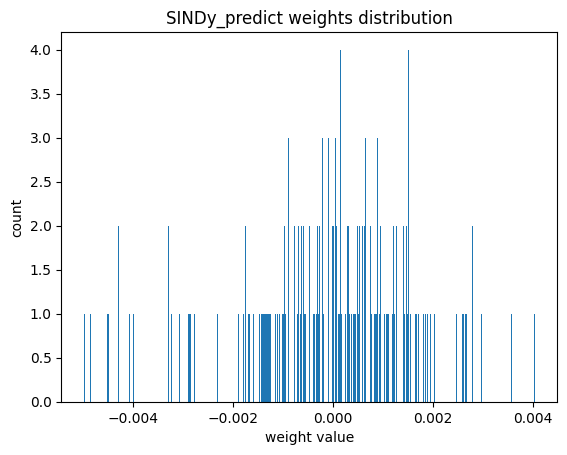

In [2]:
# grab weights/bias (handle optional bias safely)
W = autoencoder.model.SINDy_predict.weight.detach().cpu()
bias = autoencoder.model.SINDy_predict.bias
b = None if bias is None else bias.detach().cpu()

# sparsity stats (FIX: count nonzeros, not zeros)
thr = 1e-5  # tweak threshold for "effectively zero"
num_nonzero = (W.abs() > thr).sum().item()
total = W.numel()
print(f"Nonzeros>{thr}: {num_nonzero}/{total} ({num_nonzero/total:.2%})")

# top-10 magnitudes
k = min(10, total)
flat_vals, flat_idx = torch.topk(W.abs().flatten(), k=k)
print(f"Top-{k} |weights|:")
for v, idx in zip(flat_vals.tolist(), flat_idx.tolist()):
    row, col = divmod(idx, W.size(1))
    print(f"row {row}, col {col}, value {W[row, col].item():+.4e}, |.|={v:.4e}")

# optional: histogram of magnitudes
import matplotlib.pyplot as plt
plt.hist(W.flatten().numpy(), bins=500)
plt.title("SINDy_predict weights distribution")
plt.xlabel("weight value")
plt.ylabel("count")
plt.show()


In [3]:
import torch
from torch.utils.data import DataLoader
from datasets import WRsmallepoch

# Keep dtype explicit to match model expectations
torch.set_default_dtype(torch.float32)


def get_example_batch(
    data_file="/app/Data/WR/WR5_Run4.hdf5",
    annotation_file="/app/Data/WR/Annotations/260218_annotations_a.pkl",
    batch_size=4,
    single_channel=True,
    psd=False,
    epoch_id=2,
    epoch_size=5.0,
    sample_rate=5000,
    shuffle=True,
):
    ds = WRsmallepoch(
        data_file=data_file,
        annotation_file=annotation_file,
        single_channel_flag=single_channel,
        psd_flag=psd,
        epoch_id_restriction=epoch_id,
        epoch_size=epoch_size,
        sample_rate=sample_rate,
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    data, labels = next(iter(loader))
    print(f"data shape: {tuple(data.shape)}, dtype: {data.dtype}")
    print(f"labels shape: {tuple(labels.shape)}, labels: {labels.tolist()}")
    return data, labels, ds.freq_weights

# Example usage in a notebook cell
data, labels, freq_weights = get_example_batch()


data shape: (4, 500), dtype: torch.float32
labels shape: (4,), labels: [2, 2, 2, 2]


data shape: (4, 500), dtype: torch.float32
labels shape: (4,), labels: [2, 2, 2, 2]
Per-item RMSE: [1.168124794960022, 2.4664247035980225, 1.5821380615234375, 1.6709206104278564]


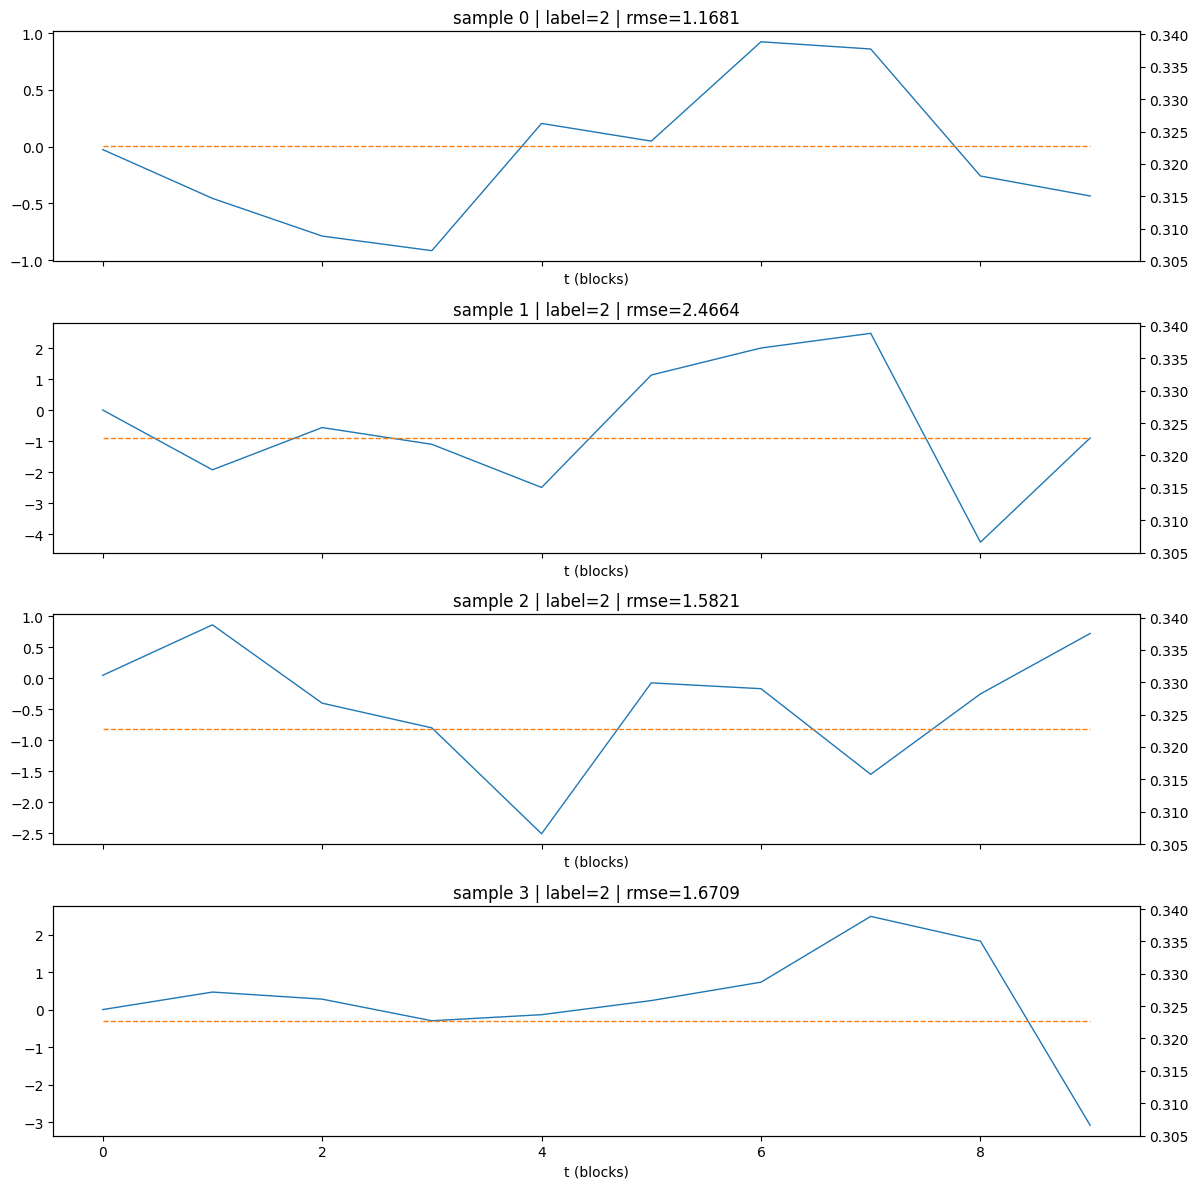

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from model import reshape_time_to_feature_blocks

autoencoder = autoencoder.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))


def _adapt_to_model_input(x, block_size=50):
    """
    Produces [B, new_T, block_size] where block_size should equal model.system_features.
    For multi-channel inputs [B,T,C], folds C into time: T' = T*C.
    """
    if x.dim() == 2:
        B, T = x.shape
        return reshape_time_to_feature_blocks(x, time_dim=T, block_size=block_size)

    if x.dim() == 3:
        B, T, C = x.shape
        if C == 1:
            return reshape_time_to_feature_blocks(x, time_dim=T, block_size=block_size)

        x_flat = x.reshape(B, T * C)  # [B, T*C]
        return reshape_time_to_feature_blocks(x_flat, time_dim=T * C, block_size=block_size)

    raise ValueError(f"Expected x with 2 or 3 dims, got {tuple(x.shape)}")


def inspect_recon_batch_dual_axes(data, labels=None, max_items=4, title_prefix="sample"):
    device = next(autoencoder.parameters()).device
    dtype = next(autoencoder.parameters()).dtype

    # IMPORTANT: block_size must match what the checkpoint/model expects as system_features
    block_size = autoencoder.model.system_features  # e.g., 50
    data_adapted = _adapt_to_model_input(data, block_size=block_size)

    data_plot = data_adapted.detach().cpu()
    data_model = data_adapted.detach().clone().to(device=device, dtype=dtype)
    labels_model = None if labels is None else labels.to(device)

    # forward needs autograd for jacobians; don't use no_grad
    _, x_hat, _, _, _, _ = autoencoder(data_model)
    x_hat_plot = x_hat.detach().cpu()

    per_item_rmse = F.mse_loss(x_hat_plot, data_plot, reduction="none").mean(dim=(1, 2)).sqrt()

    n = min(max_items, data_plot.size(0))
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    t = torch.arange(data_plot.size(1))
    ch = 0  # plot one feature for readability
    for i in range(n):
        ax_left = axes[i]
        ax_right = ax_left.twinx()

        ax_left.plot(t, data_plot[i, :, ch], color="tab:blue", lw=1, label="input (feat0)")
        ax_right.plot(t, x_hat_plot[i, :, ch], color="tab:orange", lw=1, linestyle="--", label="recon (feat0)")

        label_str = f"{labels_model[i].item()}" if labels_model is not None else "None"
        ax_left.set_title(f"{title_prefix} {i} | label={label_str} | rmse={per_item_rmse[i]:.4f}")
        ax_left.set_xlabel("t (blocks)")

    plt.tight_layout()
    return per_item_rmse


data, labels, freq_weights = get_example_batch()
rmse = inspect_recon_batch_dual_axes(data, labels)
print("Per-item RMSE:", rmse.tolist())

data shape: (4, 500), dtype: torch.float32
labels shape: (4,), labels: [2, 2, 2, 2]
tensor(7.1343e-05)
Per-item RMSE: [0.01776600442826748, 0.005714407656341791, 0.009060380980372429, 0.004808233119547367]


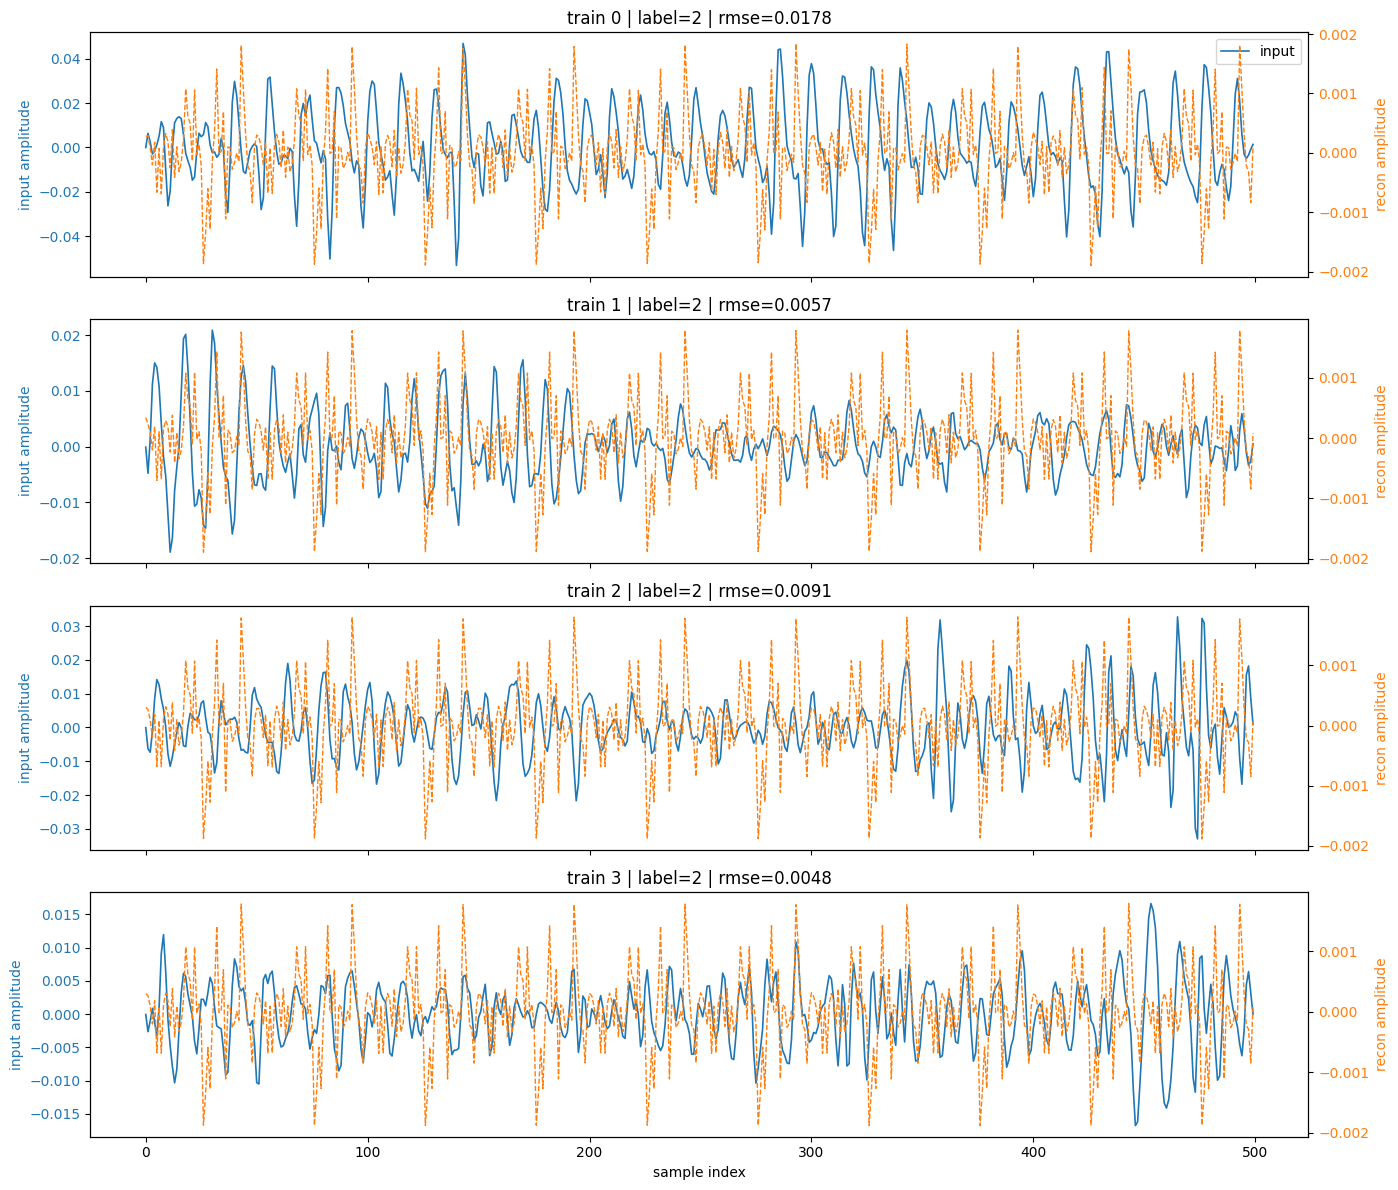

In [13]:
import matplotlib.pyplot as plt
import torch.nn.functional as F


def _unfold_feature_blocks(x_blocks: torch.Tensor) -> torch.Tensor:
    """
    Inverse of reshape_time_to_feature_blocks.
    Expects shape [batch, time_blocks, block_size] and returns [batch, time_blocks * block_size].
    """
    if x_blocks.dim() != 3:
        raise ValueError(f"Expected [B, T_blocks, block], got {tuple(x_blocks.shape)}")
    b, t_blocks, block = x_blocks.shape
    return x_blocks.reshape(b, t_blocks * block)


def visualize_recon_timeseries(batch, labels=None, title_prefix="sample"):
    """
    Runs the model on `batch`, flattens the block representation back to 1D time,
    and plots original vs reconstructed traces for every sample using dual y-axes.
    """
    device = next(autoencoder.parameters()).device
    dtype = next(autoencoder.parameters()).dtype
    block_size = autoencoder.model.system_features

    data_adapted = _adapt_to_model_input(batch, block_size=block_size)
    data_plot = data_adapted.detach().cpu()
    data_model = data_adapted.detach().clone().to(device=device, dtype=dtype)

    _, x_hat, _, _, _, _ = autoencoder(data_model)
    recon_plot = x_hat.detach().cpu()

    orig_flat = _unfold_feature_blocks(data_plot)
    recon_flat = _unfold_feature_blocks(recon_plot)
    print((recon_flat[0] - recon_flat[1]).abs().max())

    per_item_rmse = F.mse_loss(
        recon_flat, orig_flat, reduction="none"
    ).mean(dim=1).sqrt()

    n = orig_flat.size(0)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    t = torch.arange(orig_flat.size(1))
    for i, ax_left in enumerate(axes):
        ax_right = ax_left.twinx()

        ax_left.plot(t, orig_flat[i], lw=1.2, color="tab:blue", label="input")
        ax_right.plot(
            t,
            recon_flat[i],
            lw=1.0,
            linestyle="--",
            color="tab:orange",
            label="recon",
        )

        label_str = f"{labels[i].item()}" if labels is not None else "None"
        ax_left.set_title(
            f"{title_prefix} {i} | label={label_str} | rmse={per_item_rmse[i]:.4f}"
        )
        ax_left.set_ylabel("input amplitude", color="tab:blue")
        ax_right.set_ylabel("recon amplitude", color="tab:orange")

        ax_left.tick_params(axis="y", labelcolor="tab:blue")
        ax_right.tick_params(axis="y", labelcolor="tab:orange")

    axes[-1].set_xlabel("sample index")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    return per_item_rmse


# Example usage on a fresh batch:
data, labels, _ = get_example_batch()
rmse_ts = visualize_recon_timeseries(data, labels, title_prefix="train")
print("Per-item RMSE:", rmse_ts.tolist())

In [19]:
print((recon_flat[0] - recon_flat[1]).abs().max())


NameError: name 'recon_flat' is not defined

In [71]:
import torch
import pandas as pd
from itertools import combinations_with_replacement

# autoencoder already loaded from checkpoint
# autoencoder = SINDySz.load_from_checkpoint(checkpoint, model=core)

def _library_feature_names(latent_features=4, poly_order=2):
    names = []
    idx_range = list(range(latent_features))
    # polynomial terms first (same order as compute_library)
    for n in range(1, poly_order + 1):
        for combo in combinations_with_replacement(idx_range, n):
            combo_str = "*".join([f"z{c}" for c in combo])
            names.append(f"poly{n}_{combo_str}")
    # linear latent
    names.extend([f"z{c}" for c in idx_range])
    # Hilbert real/imag
    names.extend([f"hilbert_real_z{c}" for c in idx_range])
    names.extend([f"hilbert_imag_z{c}" for c in idx_range])
    return names

def list_nonzero_sindy_weights(threshold=1e-6):
    weight = autoencoder.model.SINDy_predict.weight.detach().cpu()  # [latent_features, library_dim]
    lf = weight.size(0)
    names = _library_feature_names(latent_features=lf, poly_order=autoencoder.model.poly_order)
    df = (
        pd.DataFrame(weight.numpy(), columns=names)
        .melt(ignore_index=False, var_name="feature", value_name="weight")
        .reset_index(names="latent_idx")
    )
    df["abs"] = df["weight"].abs()
    nz = df[df["abs"] > threshold].sort_values("abs", ascending=False)
    print(f"Non-zero (>|{threshold}|) weights: {len(nz)} of {len(df)}")
    return nz

nz_weights = list_nonzero_sindy_weights(threshold=1e-4)
display(nz_weights)


Non-zero (>|0.0001|) weights: 4 of 104


,latent_idx,feature,weight,abs
101,1,hilbert_imag_z3,0.000205,0.000205
8,0,poly1_z2,0.000169,0.000169
97,1,hilbert_imag_z2,0.000167,0.000167
56,0,z0,-0.000125,0.000125


In [72]:
import torch
from itertools import combinations_with_replacement

# assumes autoencoder = SINDySz.load_from_checkpoint(...)

def _library_feature_names(latent_features, poly_order):
    names = []
    idx_range = list(range(latent_features))
    for n in range(1, poly_order + 1):
        for combo in combinations_with_replacement(idx_range, n):
            names.append("*".join([f"z{k}" for k in combo]))
    names.extend([f"z{k}" for k in idx_range])
    names.extend([f"hilbert_real_z{k}" for k in idx_range])
    names.extend([f"hilbert_imag_z{k}" for k in idx_range])
    return names


def print_sindy_equations(model, threshold=1e-6):
    W = model.model.SINDy_predict.weight.detach().cpu()  # [L, library_dim]
    lf = W.size(0)
    names = _library_feature_names(lf, model.model.poly_order)
    for r in range(lf):
        terms = [f"{W[r, c].item():+0.3e}*{names[c]}" for c in range(W.size(1)) if abs(W[r, c]) > threshold]
        rhs = " + ".join(terms) if terms else "0"
        print(f"dz{r}/dt = {rhs}")

print_sindy_equations(autoencoder, threshold=1e-4)


dz0/dt = +1.692e-04*z2 + -1.247e-04*z0
dz1/dt = +1.673e-04*hilbert_imag_z2 + +2.047e-04*hilbert_imag_z3
dz2/dt = 0
dz3/dt = 0


test data shape: (4, 500, 2), labels shape: (4,)


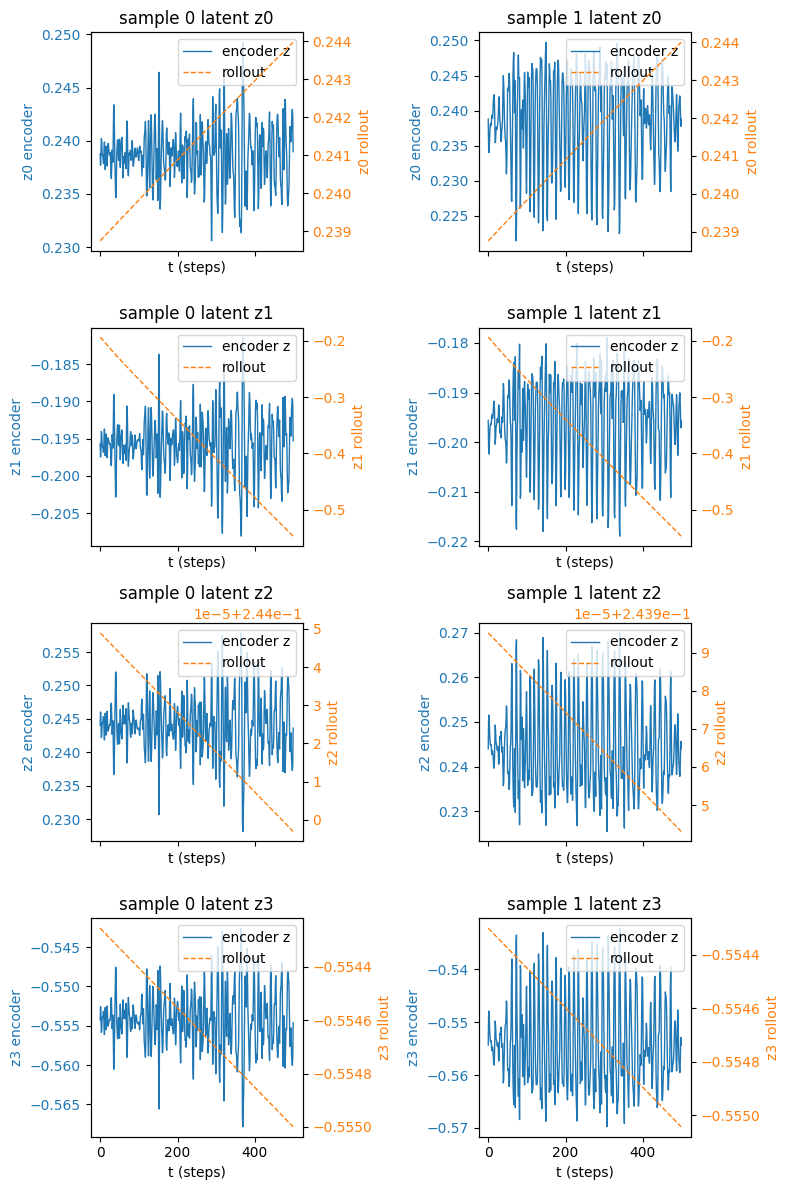

In [73]:
import torch
import matplotlib.pyplot as plt

autoencoder = autoencoder.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

@torch.no_grad()
def latent_rollout_full_dual_axes(x_batch, steps=500, dt=1.0, max_items=2):
    """Roll out all latents with the full learned SINDy field and plot encoder vs rollout.

    Args:
        x_batch: input batch (B,T[,F])
        steps: rollout steps (clipped to observed T if smaller)
        dt: Euler step size
        max_items: max samples to plot
    Returns:
        (z_true_cpu, z_roll_cpu) on CPU
    """
    model = autoencoder.model
    device = next(autoencoder.parameters()).device
    dtype = next(autoencoder.parameters()).dtype

    # encode to latent
    if x_batch.dim() == 2:
        x_batch = x_batch.unsqueeze(-1)
    x_batch = x_batch.to(device=device, dtype=dtype)
    _, _, z_true, _, _, _ = autoencoder(x_batch)  # [B, T, L]

    B, T, L = z_true.shape
    steps = min(steps, max(T, steps))

    # rollout all latents using full compute_library + SINDy_predict
    z_roll = torch.zeros((B, steps, L), device=device, dtype=dtype)
    z_roll[:, 0, :] = z_true[:, 0, :]
    for t in range(steps - 1):
        theta = model.compute_library(z_roll[:, : t + 1, :])  # features from current rollout
        y_hat = model.SINDy_predict(theta)                    # dz/dt
        dz = y_hat[:, -1, :]
        z_roll[:, t + 1, :] = z_roll[:, t, :] + dt * dz       # Euler step

    # detach for plotting
    z_true_cpu = z_true[:, :steps, :].detach().cpu()
    z_roll_cpu = z_roll[:, :steps, :].detach().cpu()

    n = min(max_items, B)
    fig, axes = plt.subplots(L, n, figsize=(4 * n, 3 * L), sharex=True)
    if L == 1 and n == 1:
        axes = [[axes]]
    elif L == 1:
        axes = [axes]
    elif n == 1:
        axes = [[ax] for ax in axes]

    t_axis = torch.arange(steps)
    for l in range(L):  # z0..z3
        for bi in range(n):
            ax_left = axes[l][bi]
            ax_right = ax_left.twinx()

            ax_left.plot(t_axis, z_true_cpu[bi, :, l], color="tab:blue", lw=1, label="encoder z")
            ax_left.set_ylabel(f"z{l} encoder", color="tab:blue")
            ax_left.tick_params(axis='y', labelcolor="tab:blue")

            ax_right.plot(t_axis, z_roll_cpu[bi, :, l], color="tab:orange", lw=1, linestyle="--", label="rollout")
            ax_right.set_ylabel(f"z{l} rollout", color="tab:orange")
            ax_right.tick_params(axis='y', labelcolor="tab:orange")

            ax_left.set_title(f"sample {bi} latent z{l}")
            ax_left.set_xlabel("t (steps)")
            handles = [
                plt.Line2D([0], [0], color="tab:blue", lw=1, label="encoder z"),
                plt.Line2D([0], [0], color="tab:orange", lw=1, linestyle="--", label="rollout"),
            ]
            ax_left.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    return z_true_cpu, z_roll_cpu

# Example usage
test_data, test_labels = get_test_batch()
z_true_cpu, z_roll_cpu = latent_rollout_full_dual_axes(test_data)
